# Task-3 Report: Transformer 基础结构

## 与 request.md 对齐清单
- 子任务1：多位数加法（自行生成数据）。
- 子任务1：不同训练/测试划分验证泛化性（`easy / iid / 原始`）。
- 子任务1：尝试 decoder-only 变种。
- 子任务2：语言模型（自行准备语料），并做参数对照。
- 结果可视化：表格 + 图表。

## 代码实现要点
- 数据构造：`src/task3/data_gen.py`
- 编码器-解码器 Transformer（加法任务）：`src/task3/train_addition.py`
- decoder-only 变种（加法）：`src/task3/train_addition_decoder.py`
- decoder-only 语言模型：`src/task3/train_lm.py`

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path('/home/df_05/A_fnlp/pytorch')

# ---- Addition runs ----
add_rows = []
for p in (ROOT / 'outputs/task3').glob('**/metrics.json'):
    m = json.loads(p.read_text(encoding='utf-8'))
    if 'best_test_exact' not in m:
        continue
    cfg_p = p.parent / 'config.json'
    c = json.loads(cfg_p.read_text(encoding='utf-8')) if cfg_p.exists() else {}
    rel = p.parent.relative_to(ROOT / 'outputs/task3')
    group = rel.parts[0] if len(rel.parts) > 1 else 'root'
    run = p.parent.name
    split = 'easy' if 'easy' in run or 'easy' in str(c.get('train_tsv', '')) else ('iid' if 'iid' in run or 'iid' in str(c.get('train_tsv', '')) else 'base')
    model_variant = 'decoder_only' if 'decoder' in run else 'seq2seq'
    add_rows.append({
        'run': run,
        'group': group,
        'split': split,
        'model_variant': model_variant,
        'd_model': c.get('d_model'),
        'nhead': c.get('nhead'),
        'reverse_src': c.get('reverse_src', False),
        'reverse_tgt': c.get('reverse_tgt', False),
        'best_test_exact': m.get('best_test_exact'),
        'path': str(p.parent),
    })
df_add = pd.DataFrame(add_rows).sort_values('best_test_exact', ascending=False).reset_index(drop=True)
display(df_add[['run','group','split','model_variant','d_model','nhead','reverse_src','reverse_tgt','best_test_exact']].head(20))
best_add = df_add.iloc[0]
print('Best addition run:', best_add['run'], 'best_test_exact=', round(float(best_add['best_test_exact']), 4))

,run,group,split,model_variant,d_model,nhead,reverse_src,reverse_tgt,best_test_exact
0,add_easy_rev_big,best,easy,seq2seq,256,8,True,True,0.148333
1,add_easy_rev,best,easy,seq2seq,128,4,True,True,0.112500
2,add_easy,root,easy,seq2seq,128,4,False,False,0.051667
3,add_iid_rev_finetune,best,iid,seq2seq,256,8,True,True,0.015833
4,add_easy_decoder_only,root,easy,decoder_only,128,4,False,False,0.010000
5,add_iid_rev,best,iid,seq2seq,128,4,True,True,0.005000
6,add_iid,root,iid,seq2seq,128,4,False,False,0.002500
7,add_iid_rev_big,best,iid,seq2seq,256,8,True,True,0.001667
8,exp_add_01_d64_h2,final,base,seq2seq,64,2,False,False,0.000500
9,exp_add_02_d128_h2,final,base,seq2seq,128,2,False,False,0.000500


Best addition run: add_easy_rev_big best_test_exact= 0.1483


,split,best_test_exact
1,easy,0.148333
2,iid,0.015833
0,base,0.000500


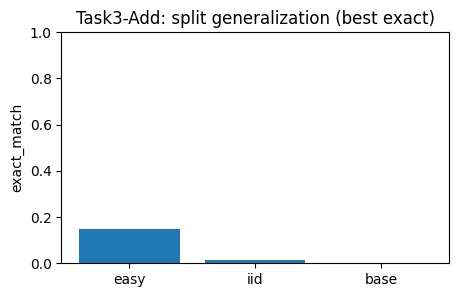

In [2]:
# 1) 子任务1：不同划分（easy/iid/base）的泛化对照
split_cmp = df_add.groupby('split', as_index=False)['best_test_exact'].max().sort_values('best_test_exact', ascending=False)
display(split_cmp)
plt.figure(figsize=(5,3))
plt.bar(split_cmp['split'], split_cmp['best_test_exact'])
plt.ylim(0.0, 1.0)
plt.title('Task3-Add: split generalization (best exact)')
plt.ylabel('exact_match')
plt.show()

,model_variant,best_test_exact
1,seq2seq,0.148333
0,decoder_only,0.010000


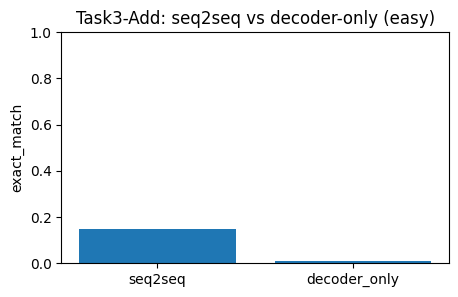

In [3]:
# 2) 子任务1：decoder-only 变种对照（easy 划分）
easy = df_add[df_add['split'] == 'easy']
variant_cmp = easy.groupby('model_variant', as_index=False)['best_test_exact'].max().sort_values('best_test_exact', ascending=False)
display(variant_cmp)
plt.figure(figsize=(5,3))
plt.bar(variant_cmp['model_variant'], variant_cmp['best_test_exact'])
plt.ylim(0.0, 1.0)
plt.title('Task3-Add: seq2seq vs decoder-only (easy)')
plt.ylabel('exact_match')
plt.show()

In [4]:
# 3) 子任务1：参数/技巧影响（reverse 与更大模型）
cols = ['run','split','d_model','nhead','reverse_src','reverse_tgt','best_test_exact']
display(df_add[cols].sort_values('best_test_exact', ascending=False).head(12))

,run,split,d_model,nhead,reverse_src,reverse_tgt,best_test_exact
0,add_easy_rev_big,easy,256,8,True,True,0.148333
1,add_easy_rev,easy,128,4,True,True,0.112500
2,add_easy,easy,128,4,False,False,0.051667
3,add_iid_rev_finetune,iid,256,8,True,True,0.015833
4,add_easy_decoder_only,easy,128,4,False,False,0.010000
5,add_iid_rev,iid,128,4,True,True,0.005000
6,add_iid,iid,128,4,False,False,0.002500
7,add_iid_rev_big,iid,256,8,True,True,0.001667
8,exp_add_01_d64_h2,base,64,2,False,False,0.000500
9,exp_add_02_d128_h2,base,128,2,False,False,0.000500


,run,group,d_model,nhead,seq_len,best_val_ppl,best_val_loss,path
0,req_lm_d128_seq64,req,128,4,64,10.162419,2.318696,/home/df_05/A_fnlp/pytorch/outputs/task3/req/r...
1,lm_baseline,root,128,4,96,10.483241,2.349778,/home/df_05/A_fnlp/pytorch/outputs/task3/lm_ba...
2,req_lm_d64_seq96,req,64,2,96,10.911982,2.389861,/home/df_05/A_fnlp/pytorch/outputs/task3/req/r...


Best LM run: req_lm_d128_seq64 best_val_ppl= 10.1624


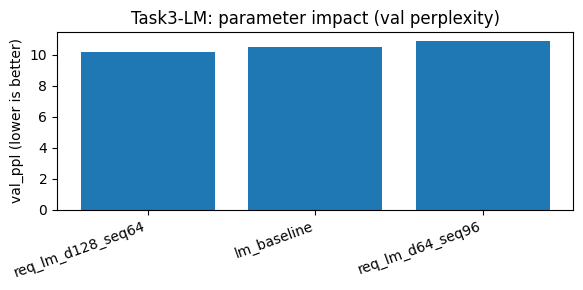

In [5]:
# ---- LM runs ----
lm_rows = []
for p in (ROOT / 'outputs/task3').glob('**/metrics.json'):
    m = json.loads(p.read_text(encoding='utf-8'))
    if 'best_val_ppl' not in m:
        continue
    cfg_p = p.parent / 'config.json'
    c = json.loads(cfg_p.read_text(encoding='utf-8')) if cfg_p.exists() else {}
    rel = p.parent.relative_to(ROOT / 'outputs/task3')
    group = rel.parts[0] if len(rel.parts) > 1 else 'root'
    lm_rows.append({
        'run': p.parent.name,
        'group': group,
        'd_model': c.get('d_model'),
        'nhead': c.get('nhead'),
        'seq_len': c.get('seq_len'),
        'best_val_ppl': m.get('best_val_ppl'),
        'best_val_loss': m.get('best_val_loss'),
        'path': str(p.parent),
    })
df_lm = pd.DataFrame(lm_rows).sort_values('best_val_ppl').reset_index(drop=True)
display(df_lm)
best_lm = df_lm.iloc[0]
print('Best LM run:', best_lm['run'], 'best_val_ppl=', round(float(best_lm['best_val_ppl']), 4))
plt.figure(figsize=(6,3))
plt.bar(df_lm['run'], df_lm['best_val_ppl'])
plt.xticks(rotation=20, ha='right')
plt.title('Task3-LM: parameter impact (val perplexity)')
plt.ylabel('val_ppl (lower is better)')
plt.tight_layout(); plt.show()

In [6]:
# 4) 样例生成文本（最佳 LM）
best_lm_path = Path(best_lm['path'])
sample_p = best_lm_path / 'sample.txt'
if sample_p.exists():
    txt = sample_p.read_text(encoding='utf-8')
    print(txt[:1200])
else:
    print('No sample.txt found at', sample_p)

this and the the the the the the the the sthe the the the the the the the sthe the the the the the sthe the the the the the t


Best addition path: /home/df_05/A_fnlp/pytorch/outputs/task3/best/add_easy_rev_big
{
  "best_epoch": 40,
  "best_test_exact": 0.14833333333333334,
  "num_train": 8000,
  "num_test": 1200,
  "vocab_size": 14,
  "device_used": "cpu"
}


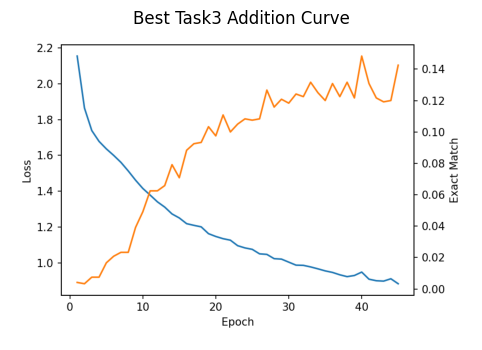

In [7]:
# 5) 最佳加法模型曲线
from PIL import Image
best_add_path = Path(best_add['path'])
print('Best addition path:', best_add_path)
print(json.dumps(json.loads((best_add_path/'metrics.json').read_text()), indent=2, ensure_ascii=False))
curve = best_add_path / 'curve.png'
if curve.exists():
    img = Image.open(curve)
    plt.figure(figsize=(8,4)); plt.imshow(img); plt.axis('off'); plt.title('Best Task3 Addition Curve'); plt.show()
else:
    print('No curve found:', curve)